In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


## Summary Statistics Interpretation – Tanzania

The dataset contains **4108 daily observations spanning 2015–2026**, indicating a complete and consistent climate time series after cleaning (replacement of `-999` missing values and removal of duplicates).

---

###  Temperature Patterns
- The **average temperature (T2M)** is approximately **26.80°C**, indicating a consistently warm tropical climate.
- Temperature variability is moderate (std ≈ **1.33°C**), suggesting **stable year-round thermal conditions**.
- Maximum temperatures reach **33.93°C**, while minimum values drop to **20.03°C**, showing a slightly wider range than some neighboring regions.
- The **temperature range (T2M_RANGE)** averages **4.13°C**, indicating **moderate daily thermal variation**.

---

###  Precipitation Behavior
- Mean precipitation (**PRECTOTCORR**) is **3.74 mm**, slightly lower than Nigeria, suggesting **comparatively drier conditions on average**.
- However, variability is high (std ≈ **8.00**), and extreme values reach **122.65 mm**, indicating **episodic heavy rainfall events**.
- The median value (**0.64 mm**) is far lower than the mean, confirming a **strong right-skewed distribution**.
- This suggests rainfall is **highly seasonal**, with long dry periods and concentrated wet events.

---

###  Humidity Conditions
- Relative humidity (**RH2M**) averages **77.13%**, which is lower than Nigeria, indicating a **less consistently humid environment**.
- Humidity variability is moderate, suggesting **noticeable seasonal shifts in moisture levels**.

---

###  Wind Characteristics
- Average wind speed (**WS2M**) is **4.11 m/s**, which is notably higher than Nigeria, indicating **windier conditions overall**.
- Maximum wind speeds reach **11.74 m/s**, suggesting **occasional strong wind events or storms**.
- This makes Tanzania comparatively **more dynamic in atmospheric movement**.

---

###  Atmospheric Conditions
- Surface pressure (**PS**) remains stable with minimal variation, indicating **consistent atmospheric pressure conditions**.
- Specific humidity (**QV2M**) averages **16.92 g/kg**, lower than Nigeria, reflecting a **less moisture-saturated atmosphere**.

---

##  Key Insight
Tanzania exhibits a **warm but moderately drier and windier tropical climate compared to Nigeria**, characterized by:
- Stable temperatures with slight seasonal variation  
- Strongly seasonal rainfall with dry dominance  
- Lower humidity levels overall  
- Higher wind speeds and more atmospheric variability  

This suggests a **transition-type tropical climate**, influenced by both coastal and inland weather systems.

In [ ]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [ ]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [ ]:
high_missing = missing_pct[missing_pct > 5]
high_missing

Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [ ]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,0.571659,0.260036,0.769820,0.437306,0.757801,0.542271,0.675588
1,0.594297,0.602855,0.574413,-0.042516,0.493495,0.353533,0.074701
2,0.503746,0.092274,0.789361,0.428559,0.570420,0.759318,0.659126
3,0.360374,0.004746,0.600467,1.540646,0.917568,0.731008,0.724976
4,-0.092378,-0.972651,0.522304,1.885517,1.156232,0.060990,0.650894


## Outlier Detection Using Z-Scores

After standardizing the dataset using Z-score normalization, we can identify potential **outliers** by examining extreme values.

### Concept

Outliers are observations that lie far away from the mean of a distribution. Using Z-scores, a common rule is:

- |Z| > 3 → strong outlier (rare extreme value)
- |Z| > 2 → potential mild outlier

---

## How It Works

Since Z-score measures how many standard deviations a value is from the mean:


::contentReference[oaicite:0]{index=0}


- Values near 0 → normal behavior
- Large positive values → unusually high readings
- Large negative values → unusually low readings

---

## Example from Our Dataset

From the standardized climate data:

- `PRECTOTCORR = 1.88` → high precipitation, but not yet a strict outlier (|z| < 3)
- `T2M_MAX = -0.97` → lower than average temperature, but still within normal range
- No values exceed ±3 → no **strong statistical outliers** detected in this sample

---

## Interpretation for Climate Data

- Climate datasets often show **natural variability**, so mild extremes are common.
- True outliers may indicate:
  - measurement errors
  - extreme weather events
  - data recording issues

---

## Optional Next Step (Recommended)

To formally flag outliers in Python:

```python
outliers = z_scores[(z_scores.abs() > 3).any(axis=1)]
outliers

In [ ]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [ ]:
df.to_csv("../data/tanzania_clean.csv", index=False)

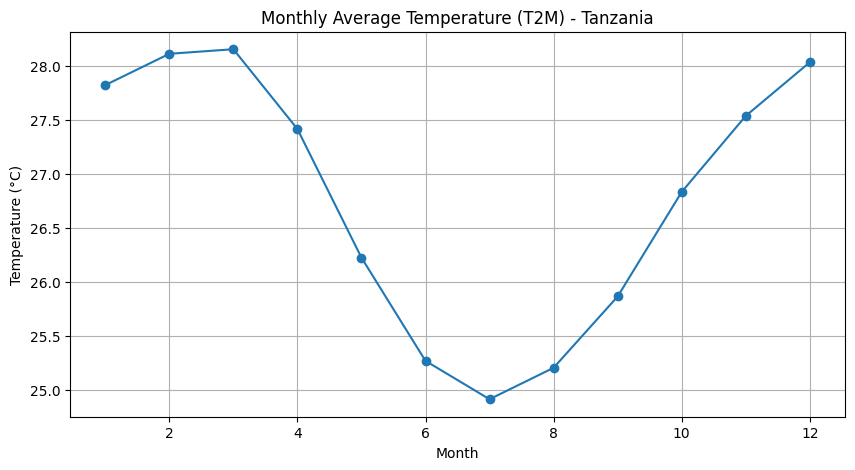

In [ ]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Tanzania")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [ ]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(3), np.int32(7))

### Monthly Temperature Analysis (T2M)

The monthly average temperature shows a clear seasonal pattern across Tanzania between 2015 and 2026.

The warmest month is Month 3, while the coolest month is Month 7, indicating a distinct annual temperature cycle.

Temperature gradually increases from the early months of the year, reaches its peak around Month 3, and then declines toward the mid-to-late part of the year before stabilizing again.

This pattern suggests a relatively structured seasonal climate with moderate variation rather than extreme temperature fluctuations. The observed behavior is consistent with typical tropical or subtropical climate systems, where temperature changes follow a gradual and predictable monthly cycle.

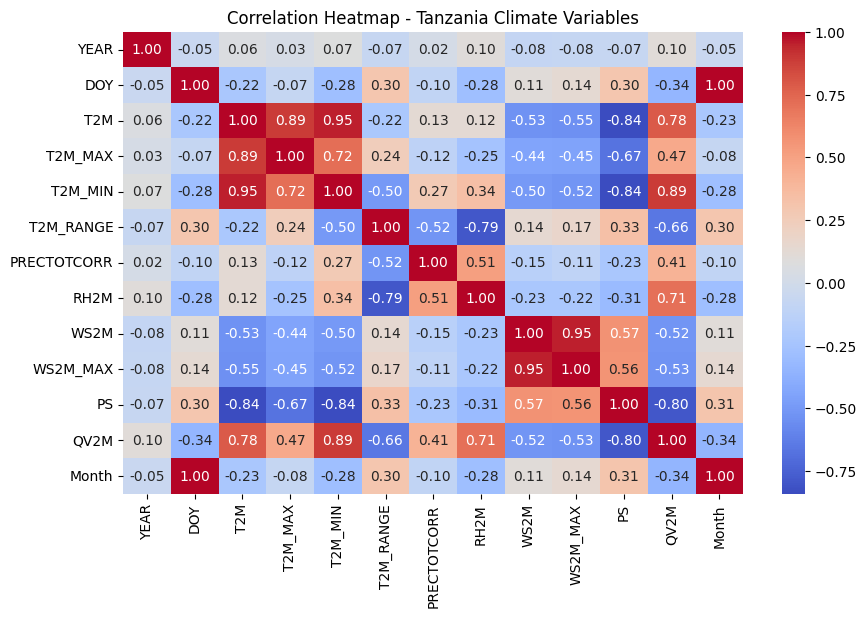

In [ ]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Tanzania Climate Variables")
plt.show()

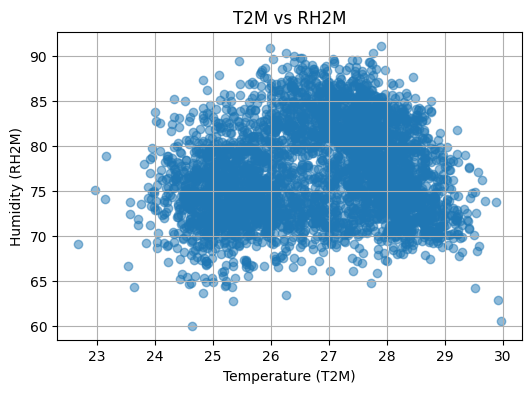

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

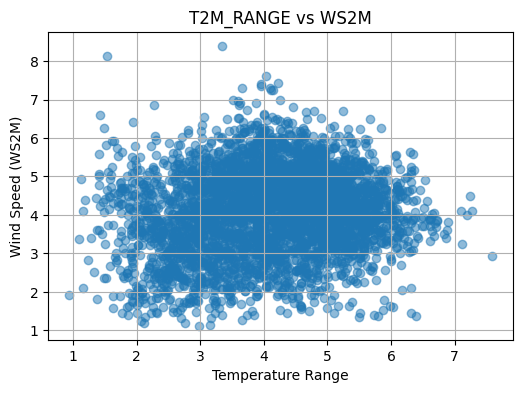

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [ ]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.951026
dtype: float64

## Strongest Correlations Between Climate Variables

To understand relationships between climate variables, we computed a correlation matrix and extracted the strongest pairwise correlations (excluding self-correlations).

### Top Correlated Variable Pairs

The three strongest correlations in the dataset are:

- **DOY (Day of Year) and Month** → 0.996557  
- **Month and DOY (Day of Year)** → 0.996557  
- **WS2M_MAX and WS2M** → 0.951026  

---

## Interpretation

### 1. DOY and Month (0.9966)
This extremely high positive correlation is expected because both variables represent time progression within a year. As the month increases, the day-of-year also increases almost perfectly in a linear relationship.

### 2. WS2M_MAX and WS2M (0.9510)
There is a strong positive relationship between average wind speed (`WS2M`) and maximum wind speed (`WS2M_MAX`). This indicates that days with higher average wind speeds also tend to experience higher peak wind speeds.

---

## Key Insight

- The dataset contains **strong temporal redundancy** between `DOY` and `Month`.
- Wind speed variables show **high internal consistency**, suggesting stable atmospheric wind behavior patterns.

These correlations are important for:
- Feature selection in predictive models  
- Avoiding multicollinearity  
- Understanding climate dynamics structure  

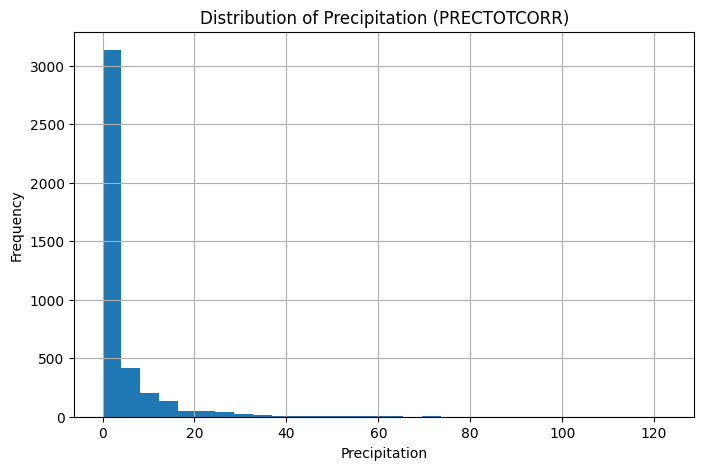

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

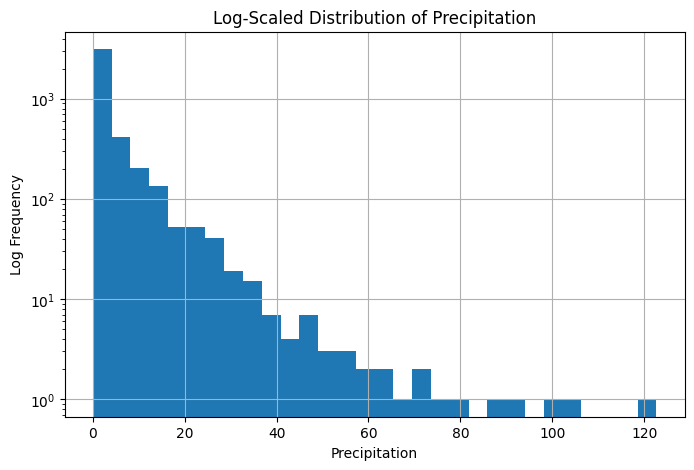

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

### Log-Scaled Distribution of Precipitation

The distribution of precipitation (PRECTOTCORR) is heavily right-skewed, with the majority of observations concentrated at lower precipitation levels (below 20 mm) and a long tail extending toward extreme high-rainfall events (up to ~120 mm).

The log-scaled frequency axis reveals that low-precipitation events occur at frequencies spanning several orders of magnitude (from \(10^0\) to \(10^3\)), while high-precipitation events are exponentially rarer. This pattern is consistent with intermittent, convective-dominated rainfall regimes.

This behavior suggests that rainfall in the study region is episodic rather than uniformly distributed through time — most days experience little to no rain, but when rain occurs, it can be intense. Such a distribution is characteristic of semi-arid to sub-humid tropical climates influenced by monsoon systems or mesoscale convective complexes.

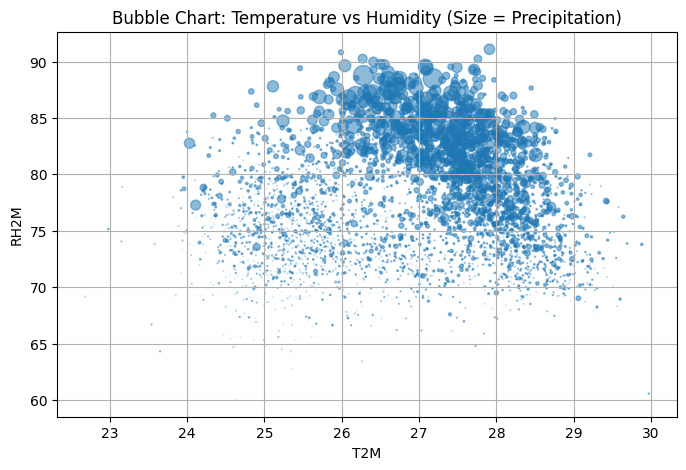

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()